<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Simple AutoEncoders with Image Data </h2> </html>

Here is a simple autoencoder with just the dense layers.


Load the data and import the libraries.

In [1]:
# Your code to import matplotlib, pandas and numpy libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

_______________________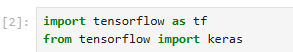

In [2]:
import tensorflow as tf
from tensorflow import keras

__________________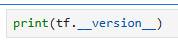

In [3]:
print(tf.__version__)

2.15.0


____________________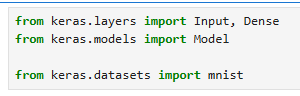

In [4]:
from keras.layers import Input, Dense
from keras.models import Model

from keras.datasets import mnist

In [5]:
# Your code to load MNIST data and store it in variables x_train, x_test. 
# Note -  we do not need labels as it's autoencoder.

from keras.datasets import mnist
(x_train, discard1), (x_test, discard2) = mnist.load_data()

______________________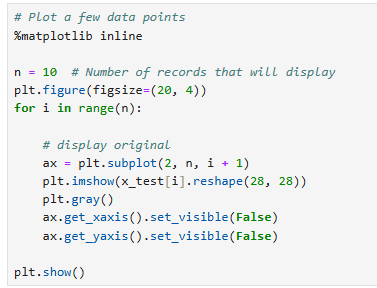

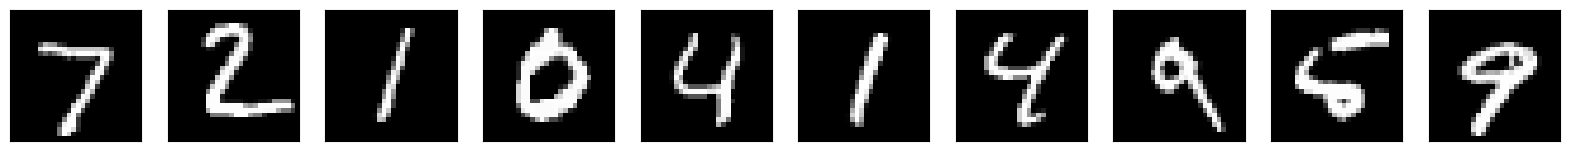

In [6]:
%matplotlib inline

n =10 
plt.figure(figsize=(20,4))

for i in range(n):

    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [7]:
# Your code to
# normalise train data - Divided by 255

x_train=x_train/255

# normalise test data - Divided by 255

x_test=x_test/255

<html> <h3 style="font-style:italic; color:blue;"> Basic AutoEncoder : </h3> </html>

Build a basic symmetric encoder-decoder network that recreates the image.  
This network could be used in dimensionaliry reduction or feature learning. 


________________________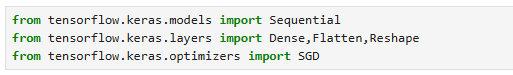

In [8]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense,Flatten,Reshape
from tensorflow.keras.optimizers import SGD

In [9]:
encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))

encoder.add(Dense(392, activation ='relu'))
encoder.add(Dense(294, activation ='relu')) #
encoder.add(Dense(196, activation ='relu'))
encoder.add(Dense(147, activation ='relu')) #
encoder.add(Dense(98,  activation ='relu'))

encoder.add(Dense(49,  activation ='relu'))

C:\Users\alexq\.conda\envs\Main\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 392)            │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 294)            │       115,542 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 196)            │        57,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 147)            │        28,959 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 98)             │        14,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 49)             │         4,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,396 (2.02 MB)

 Trainable params: 529,396 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
decoder = Sequential()
decoder.add(Dense(98,input_shape=[49],activation='relu'))

decoder.add(Dense(147, activation ='relu')) #
decoder.add(Dense(196, activation ='relu'))
decoder.add(Dense(294, activation ='relu')) #
decoder.add(Dense(392, activation ='relu'))

decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28,28]))

C:\Users\alexq\.conda\envs\Main\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 98)             │         4,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 147)            │        14,553 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 196)            │        29,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 294)            │        57,918 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 392)            │       115,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       308,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,131 (2.02 MB)

 Trainable params: 530,131 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Your OWN Encoder model should be printed here 
# Please do not copy the model below

____________________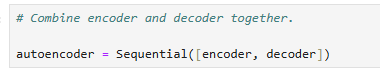

In [15]:
autoencoder = Sequential([encoder, decoder])

In [16]:
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 49)             │       529,396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │       530,131 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,059,527 (4.04 MB)

 Trainable params: 1,059,527 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Your OWN Autoencoder model should be printed here 

In [18]:
#SGD?

In [19]:
# Your code to compile the Autoencoder. 
# Use binary_crossenropy as loss and metrics as accuracy.

autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

<html> <h3 style="font-style:italic; color:red;"> If you are using a personal laptop without a GPU, change the number of epochs to 10:  

epochs=10 </h3> </html> 

___________________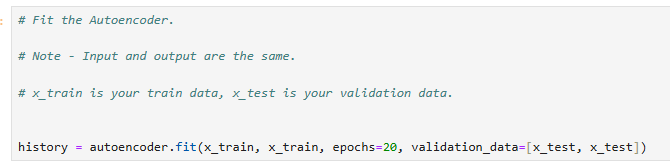

In [20]:
history = autoencoder.fit(x_train, x_train, epochs=20, validation_data=[x_test, x_test])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.1582 - loss: 0.1885 - val_accuracy: 0.2037 - val_loss: 0.1495
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.2196 - loss: 0.1411 - val_accuracy: 0.2251 - val_loss: 0.1337
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2330 - loss: 0.1322 - val_accuracy: 0.2380 - val_loss: 0.1289
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2415 - loss: 0.1271 - val_accuracy: 0.2416 - val_loss: 0.1247
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.2468 - loss: 0.1228 - val_accuracy: 0.2491 - val_loss: 0.1217
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2514 - loss: 0.1199 - val_accuracy: 0.2491 - val_loss: 0.1183
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.2555 - loss: 0.1175 - val_accuracy: 0.2527 - val_loss: 0.1158
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2595 - loss: 0

____________________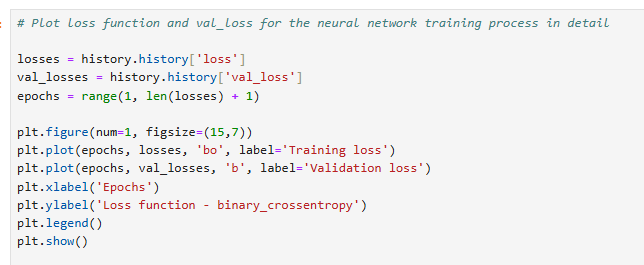

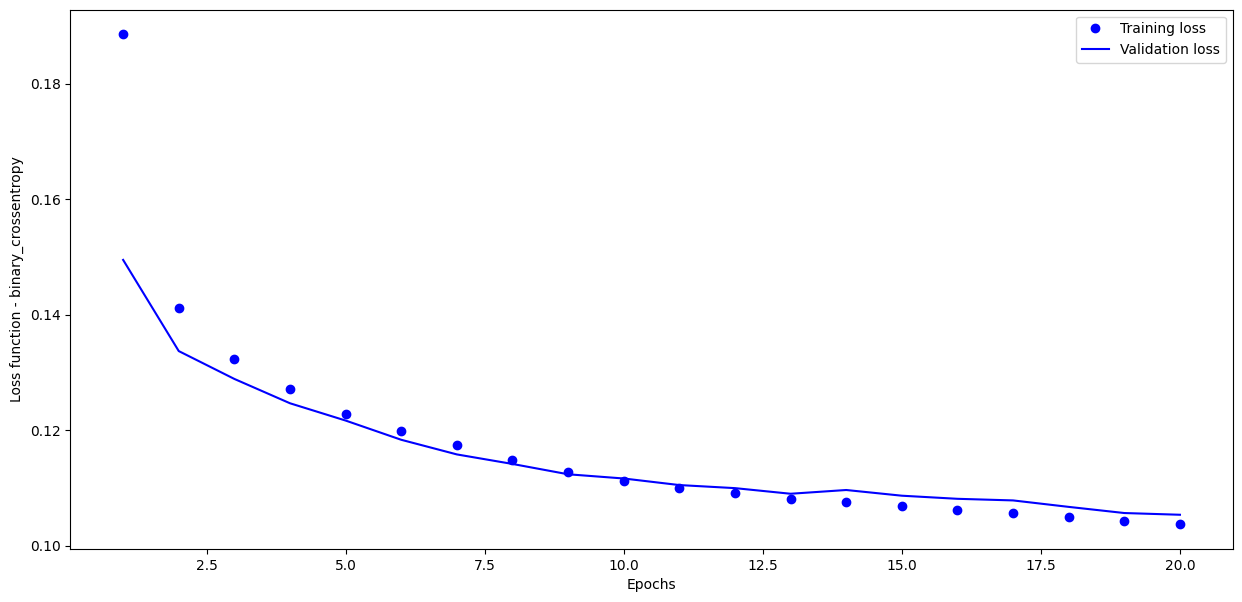

In [21]:
losses = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(losses)+1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'bo', label= 'Training loss')
plt.plot(epochs, val_loss, 'b', label= 'Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

___________________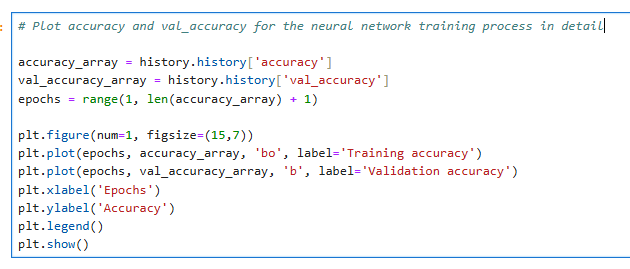

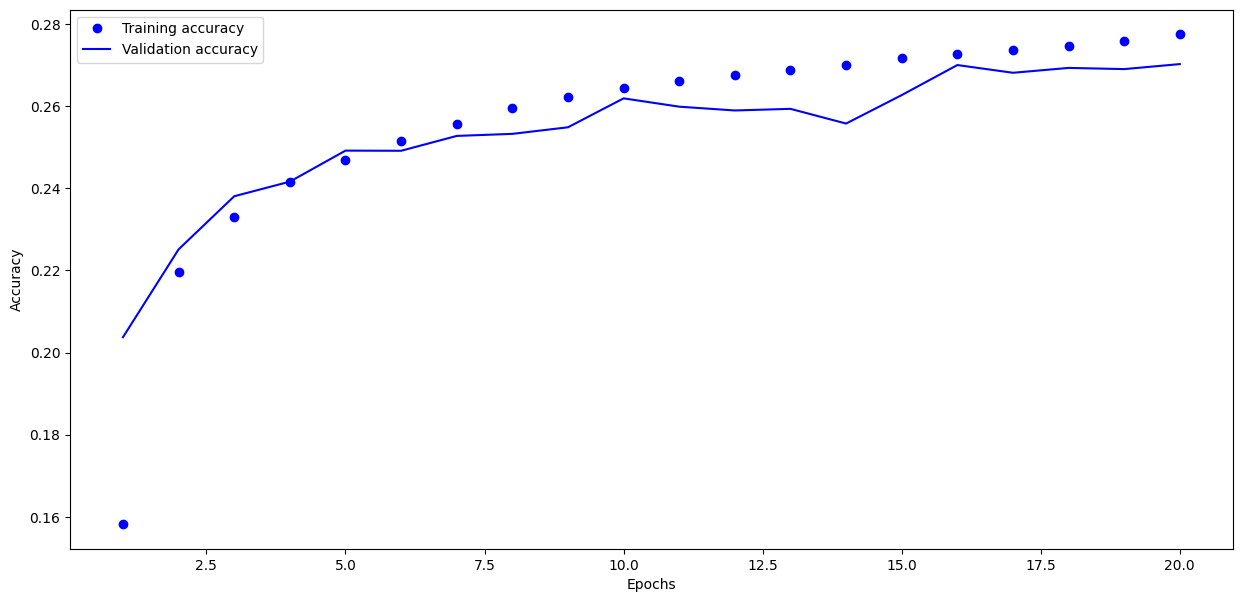

In [22]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1,figsize= (15,7))
plt.plot(epochs,accuracy_array, 'bo', label = 'Training accuracy')
plt.plot(epochs,val_accuracy_array, 'b', label= 'Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

_______________________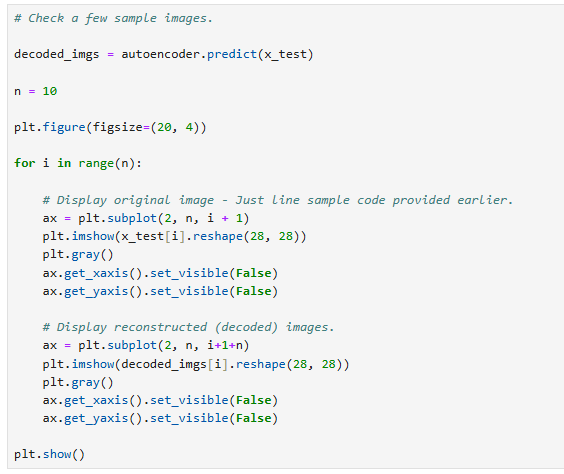

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


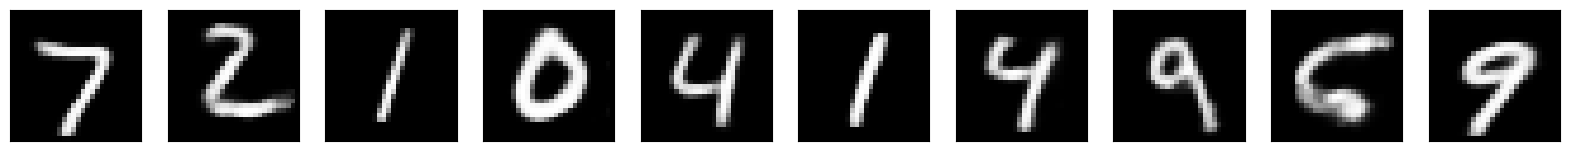

In [23]:
decoded_imgs= autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20,4))

for i in range(n):
    ax= plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax= plt.subplot(2, n, i + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

<html> <h3 style="font-style:italic; color:blue;"> AutoEncoders for Denoising Images : </h3> </html>

Use the same digit data set. Add Gaussian noise to it to train an autoencoder that removes noise. Test the noisy samples. 


______________________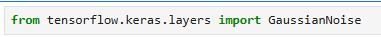

In [24]:
from tensorflow.keras.layers import GaussianNoise

In [25]:
#GaussianNoise?

___________________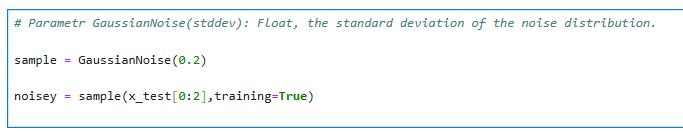

In [26]:
sample = GaussianNoise(0.2)

noisey = sample(x_test[0:2], training=True)

In [27]:
# Plot the original and noisy images

_______________________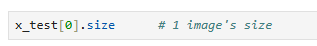

In [28]:
x_test[0].size

784

____________________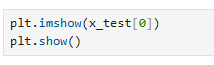

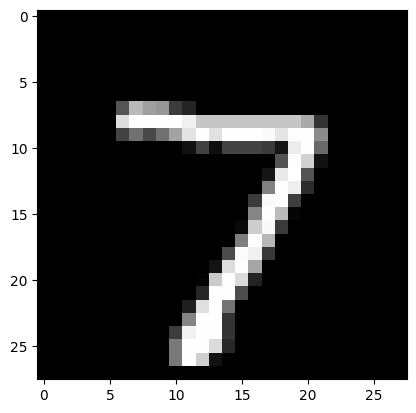

In [29]:
plt.imshow(x_test[0])
plt.show()

_____________________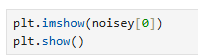

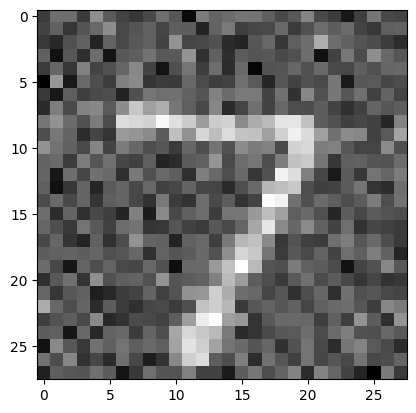

In [30]:
plt.imshow(noisey[0])
plt.show()

_________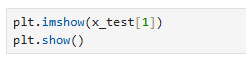

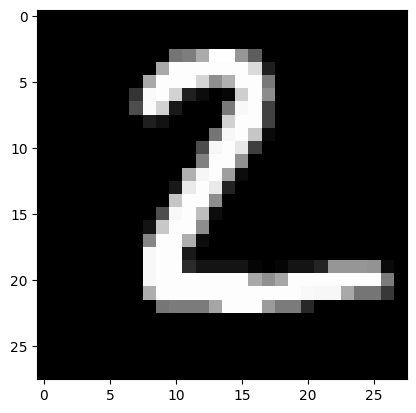

In [31]:
plt.imshow(x_test[1])
plt.show()

______________________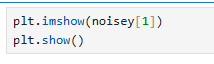

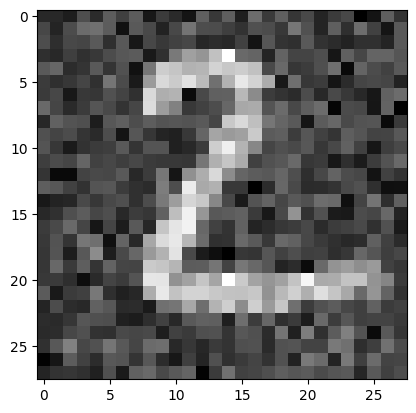

In [32]:
plt.imshow(noisey[1])
plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Create a noise removal autoencoder and train it </h4> </html>

- Again similar to above it is a symmetric dense network. 
- Gaussian noise is added at the input so that the network sees noisy images and is able to map it to the clean outputs.


### Input - Images with noise
### Labels - Clean images.


In [34]:
encoder_1 = Sequential()

encoder_1.add(Flatten(input_shape=[28,28]))
encoder_1.add(GaussianNoise(0.2)) 
encoder_1.add(Dense(392, activation ='relu'))
encoder_1.add(Dense(294, activation ='relu')) #
encoder_1.add(Dense(196, activation ='relu'))
encoder_1.add(Dense(147, activation ='relu')) #
encoder_1.add(Dense(98,  activation ='relu'))
encoder_1.add(Dense(49,  activation ='relu'))

print(encoder_1.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 784)            │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 392)            │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 294)            │       115,542 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 196)            │        57,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 147)            │        28,959 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 98)             │        14,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 49)             │         4,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,396 (2.02 MB)

 Trainable params: 529,396 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

None


In [37]:
decoder_1 = Sequential()

decoder_1.add(Dense(98,input_shape=[49],activation='relu'))
decoder_1.add(Dense(147, activation ='relu')) #
decoder_1.add(Dense(196, activation ='relu'))
decoder_1.add(Dense(294, activation ='relu')) #
decoder_1.add(Dense(392, activation ='relu'))
decoder_1.add(Dense(28 * 28, activation="sigmoid"))
decoder_1.add(Reshape([28, 28]))

print(decoder_1.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 98)             │         4,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 147)            │        14,553 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 196)            │        29,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 294)            │        57,918 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 392)            │       115,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │       308,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,131 (2.02 MB)

 Trainable params: 530,131 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

None


In [38]:
# Your OWN Decoder model should be printed here 
# Please do not copy the model below

_________________________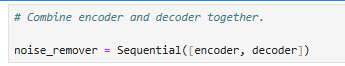

In [39]:
noise_remover = Sequential([encoder_1, decoder_1])

In [40]:
noise_remover.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 49)             │       529,396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28)         │       530,131 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,059,527 (4.04 MB)

 Trainable params: 1,059,527 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
noise_remover.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

<html> <h3 style="font-style:italic; color:red;"> If you are using a personal laptop without a GPU, you should have epochs=10 </h3> </html> 

In [42]:
# Your code to fit 'noise_remover' model with the same parameters as earlier

history_2 = noise_remover.fit(x_train, x_train, epochs=20, validation_data=[x_test, x_test])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.1663 - loss: 0.1864 - val_accuracy: 0.2022 - val_loss: 0.1564
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2175 - loss: 0.1479 - val_accuracy: 0.2280 - val_loss: 0.1380
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2284 - loss: 0.1380 - val_accuracy: 0.2353 - val_loss: 0.1331
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.2351 - loss: 0.1336 - val_accuracy: 0.2375 - val_loss: 0.1292
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2412 - loss: 0.1294 - val_accuracy: 0.2432 - val_loss: 0.1240
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.2468 - loss: 0.1255 - val_accuracy: 0.2406 - val_loss: 0.1239
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2510 - loss: 0.1229 - val_accuracy: 0.2520 - val_loss: 0.1190
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2544 - loss: 0

In [43]:
# Hint: Use (copy and modify) the code from the cells above

___________________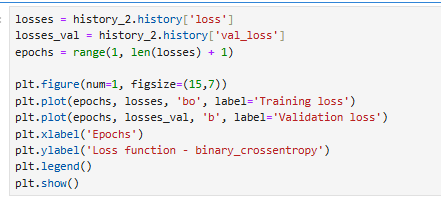

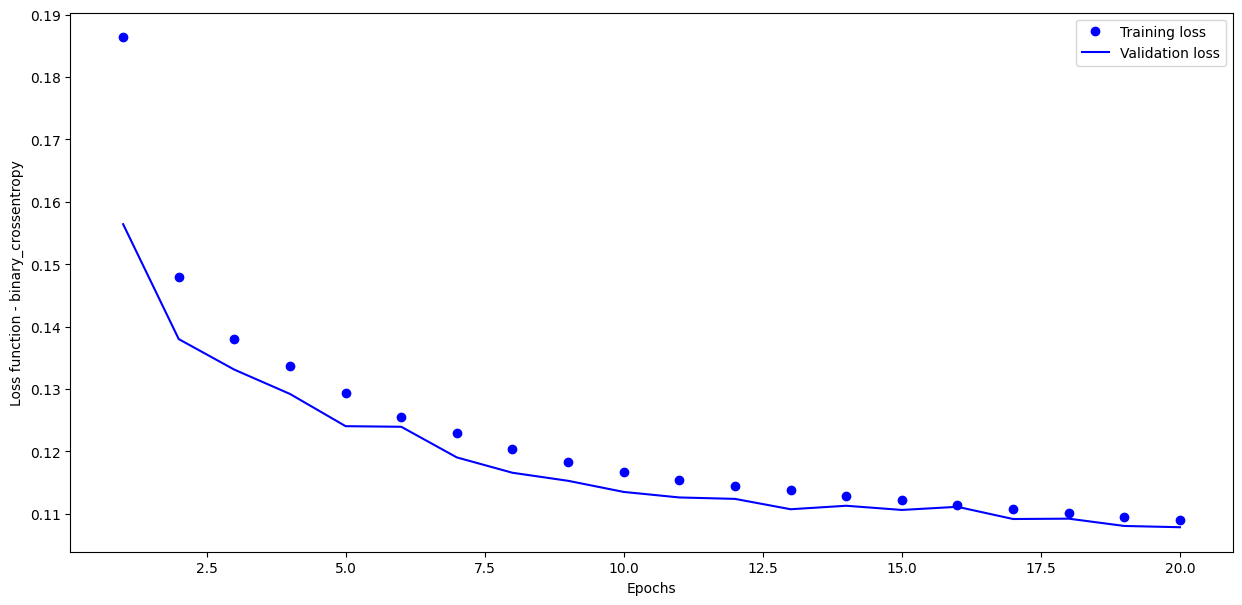

In [44]:
losses = history_2.history['loss']
losses_val = history_2.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize = (15,7))
plt.plot(epochs,losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label= 'Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

___________________________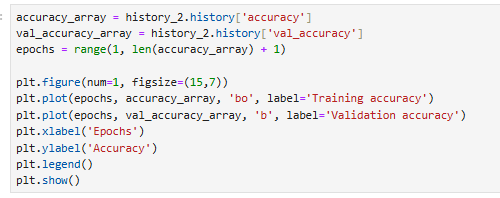

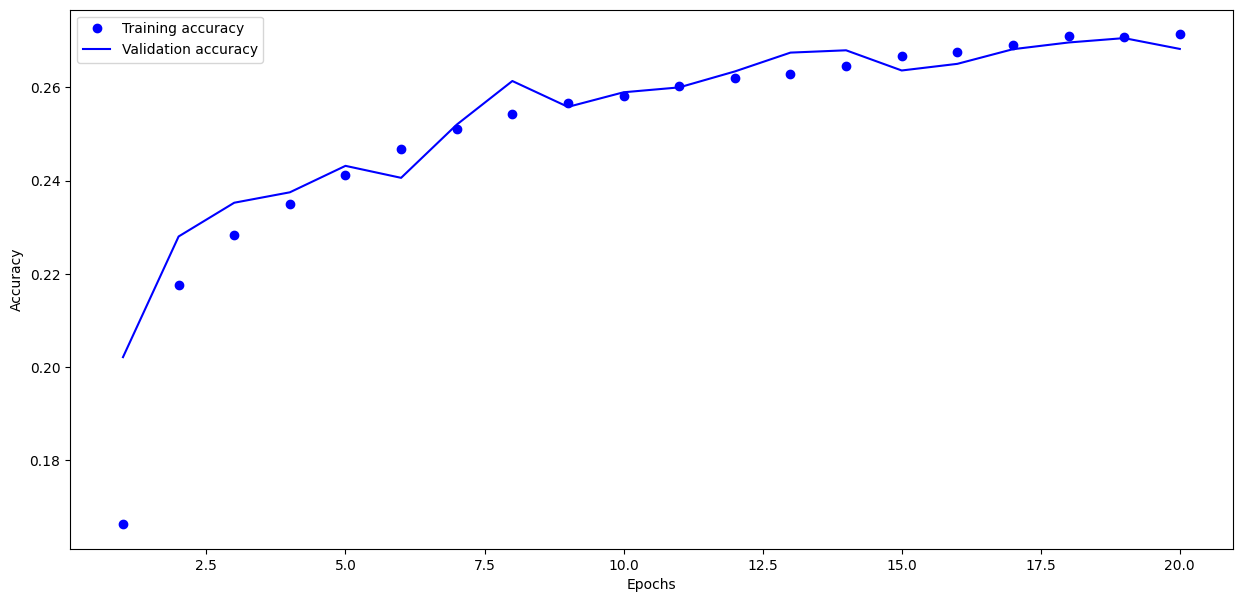

In [45]:
accuracy_array = history_2.history['accuracy']
val_accuracy_array= history_2.history['val_accuracy']
epochs = range(1,len(accuracy_array) + 1)

plt.figure(num = 1, figsize = (15,7))
plt.plot(epochs, accuracy_array, 'bo', label= 'Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label= 'Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

______________________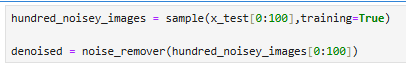

In [46]:
hundred_noisey_images = sample(x_test[0:100], training= True)

denoised = noise_remover(hundred_noisey_images[0:100])

______________________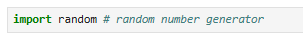

In [47]:
import random

_______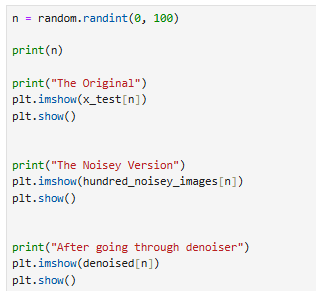

11
The Original


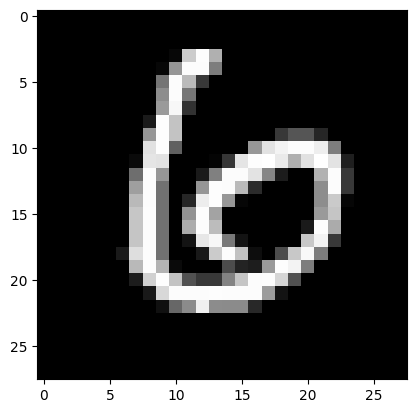

The Noisey Version


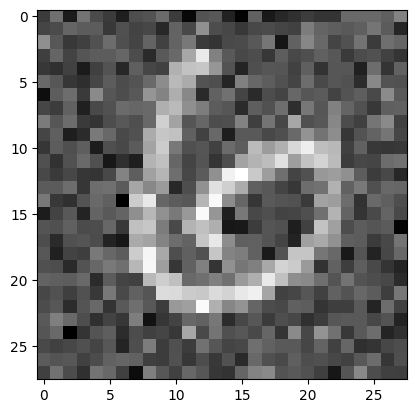

After going through denoiser


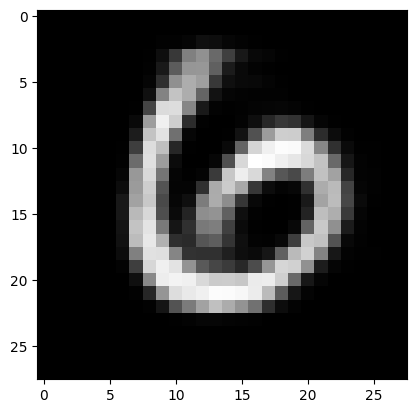

In [53]:
n = random.randint(0,100)

print(n)

print("The Original")
plt.imshow(x_test[n])
plt.show()

print("The Noisey Version")
plt.imshow(hundred_noisey_images[n])
plt.show()

print("After going through denoiser")    
plt.imshow(denoised[n])
plt.show()

<html> <h3 style="font-style:italic; color:blue;"> You can run the previous cell multiple times </h3> </html>  

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

 - Put the Encoder, Decoder and Basic Autoencoder models using summary() in your lab logbook.

Ensure that no code or other information is added to the logbook and that only required information is present. Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.

add resulting images (3 output images) so original noice decoded